# Rolling Ball Navigator

Własne środowisko Gymnasium zaimplementowane na potrzeby Projektu 4 z przedmiotu Inteligencja Obliczeniowa.

Kulka tocząca się po planszy musi dotrzeć do wyznaczonego celu, omijając statyczne przeszkody. Agent uczy się nawigacji wyłącznie na podstawie lokalnych obserwacji: prędkości, kierunku do celu i sensorów odległości (raycasting) — bez znajomości swojej pozycji absolutnej.

## 1. Środowisko `RollingBallEnv`

Środowisko spełnia standardowy interfejs Gymnasium (`reset`, `step`, `render`, `close`). Przestrzeń obserwacji jest ciągła (wektor 13 liczb `float32`), przestrzeń akcji jest ciągła (wektor 2 liczb `float32`).

| Element | Opis |
|---------|------|
| Obserwacje | `[vel_x, vel_y, goal_dx, goal_dy, goal_dist, ray_0 … ray_7]` |
| Akcje | `[fx, fy]` — siła przykładana do kulki w osi X i Y |
| Koniec epizodu | Dotarcie do celu (`terminated`) lub przekroczenie limitu kroków (`truncated`) |

In [ ]:
import math
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import pygame

WORLD_W      = 600.0
WORLD_H      = 600.0
BALL_RADIUS  = 12.0
GOAL_RADIUS  = 18.0
FRICTION     = 0.92
FORCE_SCALE  = 0.4
V_MAX        = 8.0
MAX_STEPS    = 500
RAY_MAX      = 500.0
DIAGONAL     = math.sqrt(WORLD_W ** 2 + WORLD_H ** 2)
RAY_ANGLES   = [0, 45, 90, 135, 180, 225, 270, 315]

# Static obstacle layout: (left_x, top_y, width, height)
OBSTACLES = [
    ( 80,  80,  80, 200),
    (280,  40,  80, 160),
    (440, 100, 100,  60),
    (140, 340, 160,  60),
    (350, 280,  60, 200),
    (460, 380,  90, 130),
]


class RollingBallEnv(gym.Env):

    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 30}

    def __init__(self, render_mode=None):
        super().__init__()
        assert render_mode is None or render_mode in self.metadata["render_modes"]
        self.render_mode = render_mode
        self._window = None
        self._clock  = None

        low  = np.array([-1., -1., -1., -1., 0.] + [0.] * 8, dtype=np.float32)
        high = np.array([ 1.,  1.,  1.,  1., 1.] + [1.] * 8, dtype=np.float32)
        self.observation_space = spaces.Box(low, high, dtype=np.float32)
        self.action_space = spaces.Box(
            np.array([-1.0, -1.0], dtype=np.float32),
            np.array([ 1.0,  1.0], dtype=np.float32),
            dtype=np.float32,
        )

        self._pos        = np.zeros(2, dtype=np.float32)
        self._vel        = np.zeros(2, dtype=np.float32)
        self._goal       = np.zeros(2, dtype=np.float32)
        self._step_count = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        while True:
            p = np.array([
                self.np_random.uniform(BALL_RADIUS, WORLD_W - BALL_RADIUS),
                self.np_random.uniform(BALL_RADIUS, WORLD_H - BALL_RADIUS),
            ], dtype=np.float32)
            if self._is_free(p, BALL_RADIUS):
                self._pos = p
                break

        while True:
            g = np.array([
                self.np_random.uniform(GOAL_RADIUS, WORLD_W - GOAL_RADIUS),
                self.np_random.uniform(GOAL_RADIUS, WORLD_H - GOAL_RADIUS),
            ], dtype=np.float32)
            if self._is_free(g, GOAL_RADIUS) and np.linalg.norm(g - self._pos) > 100.0:
                self._goal = g
                break

        self._vel        = np.zeros(2, dtype=np.float32)
        self._step_count = 0

        obs  = self._get_obs()
        info = self._get_info()
        if self.render_mode == "human":
            self._render_frame()
        return obs, info

    def step(self, action):
        action = np.clip(action, -1.0, 1.0).astype(np.float32)

        prev_dist = float(np.linalg.norm(self._pos - self._goal))

        self._vel  = np.clip(self._vel + action * FORCE_SCALE, -V_MAX, V_MAX)
        self._vel *= FRICTION
        self._pos += self._vel

        self._resolve_walls()
        for obs_rect in OBSTACLES:
            self._resolve_obstacle(obs_rect)

        self._step_count += 1

        dist       = float(np.linalg.norm(self._pos - self._goal))
        terminated = dist <= GOAL_RADIUS + BALL_RADIUS
        truncated  = self._step_count >= MAX_STEPS

        reward = -0.01 + 0.02 * (prev_dist - dist)
        if terminated:
            reward += 50.0

        obs  = self._get_obs()
        info = self._get_info()
        if self.render_mode == "human":
            self._render_frame()
        return obs, float(reward), terminated, truncated, info

    def render(self):
        if self.render_mode == "rgb_array":
            return self._render_frame()

    def close(self):
        if self._window is not None:
            pygame.display.quit()
            pygame.quit()
            self._window = None
            self._clock  = None

    def _is_free(self, pos: np.ndarray, radius: float) -> bool:
        if (
            pos[0] - radius < 0 or pos[0] + radius > WORLD_W
            or pos[1] - radius < 0 or pos[1] + radius > WORLD_H
        ):
            return False
        for ox, oy, ow, oh in OBSTACLES:
            cx = float(np.clip(pos[0], ox, ox + ow))
            cy = float(np.clip(pos[1], oy, oy + oh))
            if math.sqrt((pos[0] - cx) ** 2 + (pos[1] - cy) ** 2) < radius + 2.0:
                return False
        return True

    def _resolve_walls(self) -> None:
        if self._pos[0] - BALL_RADIUS < 0:
            self._pos[0] = BALL_RADIUS
            self._vel[0] = abs(self._vel[0])
        elif self._pos[0] + BALL_RADIUS > WORLD_W:
            self._pos[0] = WORLD_W - BALL_RADIUS
            self._vel[0] = -abs(self._vel[0])
        if self._pos[1] - BALL_RADIUS < 0:
            self._pos[1] = BALL_RADIUS
            self._vel[1] = abs(self._vel[1])
        elif self._pos[1] + BALL_RADIUS > WORLD_H:
            self._pos[1] = WORLD_H - BALL_RADIUS
            self._vel[1] = -abs(self._vel[1])

    def _resolve_obstacle(self, rect) -> None:
        ox, oy, ow, oh = rect
        cx = float(np.clip(self._pos[0], ox, ox + ow))
        cy = float(np.clip(self._pos[1], oy, oy + oh))
        dx = self._pos[0] - cx
        dy = self._pos[1] - cy
        dist_sq = dx * dx + dy * dy

        if dist_sq >= BALL_RADIUS * BALL_RADIUS:
            return

        dist = math.sqrt(dist_sq)
        nx, ny = (dx / dist, dy / dist) if dist > 1e-6 else (1.0, 0.0)

        overlap = BALL_RADIUS - dist
        self._pos[0] += nx * (overlap + 0.5)
        self._pos[1] += ny * (overlap + 0.5)

        dot = self._vel[0] * nx + self._vel[1] * ny
        if dot < 0:
            self._vel[0] -= 2.0 * dot * nx
            self._vel[1] -= 2.0 * dot * ny

    def _cast_ray(self, angle_deg: float) -> float:
        rad = math.radians(angle_deg)
        dx  =  math.cos(rad)
        dy  = -math.sin(rad)
        ox, oy = float(self._pos[0]), float(self._pos[1])

        t = RAY_MAX
        if dx > 1e-9:
            t = min(t, (WORLD_W - ox) / dx)
        elif dx < -1e-9:
            t = min(t, -ox / dx)
        if dy > 1e-9:
            t = min(t, (WORLD_H - oy) / dy)
        elif dy < -1e-9:
            t = min(t, -oy / dy)

        for obs_rect in OBSTACLES:
            t_obs = self._ray_aabb(ox, oy, dx, dy, obs_rect)
            if t_obs < t:
                t = t_obs

        return float(np.clip(t, 0.0, RAY_MAX))

    @staticmethod
    def _ray_aabb(ox: float, oy: float, dx: float, dy: float, rect) -> float:
        rx, ry, rw, rh = rect
        t_near, t_far = -1e30, 1e30

        if abs(dx) > 1e-9:
            tx1 = (rx      - ox) / dx
            tx2 = (rx + rw - ox) / dx
            t_near = max(t_near, min(tx1, tx2))
            t_far  = min(t_far,  max(tx1, tx2))
        elif ox < rx or ox > rx + rw:
            return RAY_MAX

        if abs(dy) > 1e-9:
            ty1 = (ry      - oy) / dy
            ty2 = (ry + rh - oy) / dy
            t_near = max(t_near, min(ty1, ty2))
            t_far  = min(t_far,  max(ty1, ty2))
        elif oy < ry or oy > ry + rh:
            return RAY_MAX

        if t_far < t_near or t_near <= 0.0:
            return RAY_MAX
        return float(np.clip(t_near, 0.0, RAY_MAX))

    def _get_obs(self) -> np.ndarray:
        ddx = self._goal[0] - self._pos[0]
        ddy = self._goal[1] - self._pos[1]
        dist = math.sqrt(ddx * ddx + ddy * ddy)
        if dist > 1e-9:
            ndx = ddx / dist
            ndy = -ddy / dist
        else:
            ndx = ndy = 0.0

        rays = [self._cast_ray(a) for a in RAY_ANGLES]
        return np.array([
            self._vel[0] / V_MAX,
            self._vel[1] / V_MAX,
            ndx,
            ndy,
            dist / DIAGONAL,
            *[r / RAY_MAX for r in rays],
        ], dtype=np.float32)

    def _get_info(self) -> dict:
        return {
            "distance_to_goal": float(np.linalg.norm(self._pos - self._goal)),
            "step": self._step_count,
        }

    def _render_frame(self):
        if not pygame.get_init():
            pygame.init()
        if self.render_mode == "human":
            if self._window is None:
                pygame.display.init()
                self._window = pygame.display.set_mode((int(WORLD_W), int(WORLD_H)))
                pygame.display.set_caption("Rolling Ball Navigator")
            if self._clock is None:
                self._clock = pygame.time.Clock()

        canvas = pygame.Surface((int(WORLD_W), int(WORLD_H)))
        TILE = 40
        for ty in range(0, int(WORLD_H), TILE):
            for tx in range(0, int(WORLD_W), TILE):
                shade = (42, 33, 24) if (tx // TILE + ty // TILE) % 2 == 0 else (50, 40, 29)
                pygame.draw.rect(canvas, shade, (tx, ty, TILE, TILE))
                pygame.draw.rect(canvas, (28, 20, 14), (tx, ty, TILE, TILE), 1)

        pygame.draw.rect(canvas, (110, 88, 64), (0, 0, int(WORLD_W), int(WORLD_H)), 6)
        pygame.draw.rect(canvas, (70, 54, 38), (3, 3, int(WORLD_W) - 6, int(WORLD_H) - 6), 2)

        for ox, oy, ow, oh in OBSTACLES:
            r = pygame.Rect(int(ox), int(oy), int(ow), int(oh))
            pygame.draw.rect(canvas, (78, 64, 48), r)
            pygame.draw.rect(canvas, (108, 90, 66), r, 2)
            pygame.draw.line(canvas, (48, 38, 28), (r.right - 1, r.top), (r.right - 1, r.bottom), 2)
            pygame.draw.line(canvas, (48, 38, 28), (r.left, r.bottom - 1), (r.right, r.bottom - 1), 2)


        obs_vec = self._get_obs()
        for i, angle_deg in enumerate(RAY_ANGLES):
            rad = math.radians(angle_deg)
            rdx =  math.cos(rad)
            rdy = -math.sin(rad)
            ray_len = float(obs_vec[5 + i]) * RAY_MAX
            ex = int(self._pos[0] + rdx * ray_len)
            ey = int(self._pos[1] + rdy * ray_len)
            pygame.draw.line(
                canvas, (210, 158, 38),
                (int(self._pos[0]), int(self._pos[1])), (ex, ey), 1,
            )

        if not hasattr(self, "_goal_img"):
            def _load_sprite(path, size):
                raw = pygame.image.load(path)
                surf = pygame.Surface(raw.get_size(), pygame.SRCALPHA)
                surf.blit(raw, (0, 0))
                return pygame.transform.scale(surf, size)
            self._goal_img  = _load_sprite("sprites/goal.png",  (int(GOAL_RADIUS * 2), int(GOAL_RADIUS * 2)))
            self._agent_img = _load_sprite("sprites/agent.png", (int(BALL_RADIUS * 2), int(BALL_RADIUS * 2)))

        canvas.blit(self._goal_img,
            (int(self._goal[0] - GOAL_RADIUS), int(self._goal[1] - GOAL_RADIUS)))
        canvas.blit(self._agent_img,
            (int(self._pos[0] - BALL_RADIUS), int(self._pos[1] - BALL_RADIUS)))

        if self.render_mode == "human":
            self._window.blit(canvas, canvas.get_rect())
            pygame.event.pump()
            pygame.display.update()
            self._clock.tick(self.metadata["render_fps"])
        else:
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(canvas)), axes=(1, 0, 2)
            )

## 2. Trening agenta (SAC)

Do treningu używamy algorytmu **Soft Actor-Critic (SAC)** z biblioteki `stable-baselines3`. SAC jest dedykowany do ciągłych przestrzeni akcji — maksymalizuje zarówno oczekiwaną nagrodę, jak i entropię polityki, co przekłada się na stabilność uczenia i dobre eksplorowanie środowiska.

Środowisko treningowe nie używa trybu graficznego (`render_mode=None`), co zapewnia maksymalną szybkość. Postęp ewaluacji jest zapisywany do pliku `logs/evaluations.npz` i wizualizowany po zakończeniu treningu.

In [ ]:
import os
from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback

os.makedirs("models", exist_ok=True)
os.makedirs("logs",   exist_ok=True)

train_env = RollingBallEnv()
eval_env  = Monitor(RollingBallEnv())

model = SAC(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    buffer_size=300_000,
    learning_starts=5_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    ent_coef=0.1,
    verbose=1,
    seed=42,
)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="models/",
    log_path="logs/",
    eval_freq=5_000,
    n_eval_episodes=10,
    deterministic=True,
    render=False,
)

model.learn(total_timesteps=500_000, callback=eval_callback)
model.save("models/rolling_ball_final")
train_env.close()
eval_env.close()
print("Trening zakończony. Model zapisany do models/rolling_ball_final.zip")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -4.58    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 4864     |
|    time_elapsed    | 0        |
|    total_timesteps | 2000     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -4.59    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 4847     |
|    time_elapsed    | 0        |
|    total_timesteps | 4000     |
---------------------------------
Eval num_timesteps=5000, episode_reward=1.37 +/- 15.83
Episode length: 486.60 +/- 40.20
---------------------------------
| eval/              |          |
|    mean_ep_length  | 487      |
|    mean_reward     | 1.37     |
|

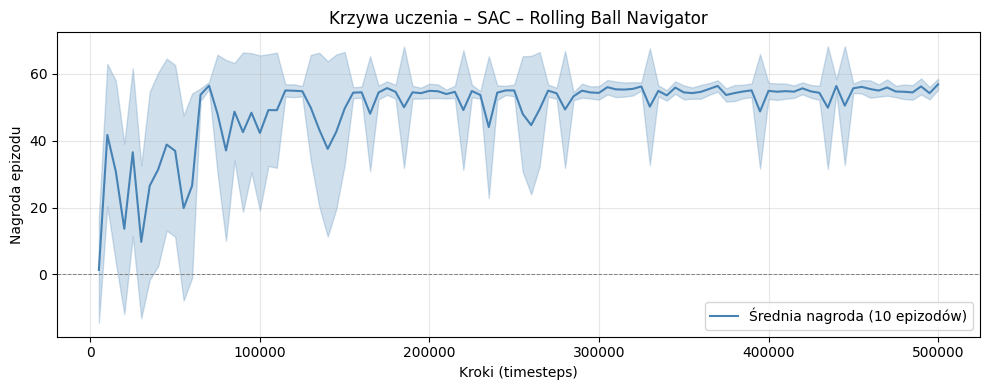

In [3]:
import matplotlib.pyplot as plt

evaluations  = np.load("logs/evaluations.npz")
timesteps    = evaluations["timesteps"]
mean_rewards = evaluations["results"].mean(axis=1)
std_rewards  = evaluations["results"].std(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(timesteps, mean_rewards, color="steelblue", label="Średnia nagroda (10 epizodów)")
ax.fill_between(
    timesteps,
    mean_rewards - std_rewards,
    mean_rewards + std_rewards,
    alpha=0.25, color="steelblue",
)
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_xlabel("Kroki (timesteps)")
ax.set_ylabel("Nagroda epizodu")
ax.set_title("Krzywa uczenia – SAC – Rolling Ball Navigator")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()

## 3. Ewaluacja

Wczytujemy najlepszy model zapisany przez `EvalCallback` i uruchamiamy go deterministycznie na zbiorze epizodów ewaluacyjnych. Mierzymy skuteczność (odsetek epizodów zakończonych sukcesem), średnią nagrodę i średnią liczbę kroków potrzebnych do dotarcia do celu.

In [14]:
from stable_baselines3 import SAC

model = SAC.load("models/best_model")

N_EVAL = 30
successes  = 0
ep_rewards = []
ep_lengths = []

eval_env = RollingBallEnv()
for ep in range(N_EVAL):
    obs, _ = eval_env.reset(seed=ep)
    total_reward = 0.0
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        if terminated or truncated:
            if terminated:
                successes += 1
            ep_rewards.append(total_reward)
            ep_lengths.append(info["step"])
            break
eval_env.close()

print(f"Wyniki ewaluacji ({N_EVAL} epizodów):")
print(f"  Skuteczność (dotarcie do celu): {successes / N_EVAL * 100:.1f}%")
print(f"  Średnia nagroda:                {np.mean(ep_rewards):.2f} ± {np.std(ep_rewards):.2f}")
print(f"  Średnia liczba kroków:          {np.mean(ep_lengths):.1f} ± {np.std(ep_lengths):.1f}")

Wyniki ewaluacji (30 epizodów):
  Skuteczność (dotarcie do celu): 100.0%
  Średnia nagroda:                54.90 ± 1.56
  Średnia liczba kroków:          123.3 ± 76.2


In [4]:
import imageio.v2 as imageio
from stable_baselines3 import SAC

model   = SAC.load("models/best_model")
rec_env = RollingBallEnv(render_mode="rgb_array")

frames = []
for ep in range(5):
    obs, _ = rec_env.reset(seed=None)
    frames.append(rec_env.render())
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = rec_env.step(action)
        frames.append(rec_env.render())
        if terminated or truncated:
            break
rec_env.close()

imageio.mimwrite("episode.mp4", frames, fps=30)
print(f"Zapisano episode.mp4 — 5 epizodów, {len(frames)} klatek ({len(frames) / 30:.1f} s @ 30 fps)")


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 600) to (608, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Zapisano episode.mp4 — 5 epizodów, 646 klatek (21.5 s @ 30 fps)


In [5]:
from stable_baselines3 import SAC

model    = SAC.load("models/best_model")
live_env = RollingBallEnv(render_mode="human")

for episode in range(10):
    obs, _ = live_env.reset()
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = live_env.step(action)
        if terminated or truncated:
            break

live_env.close()

## 4. Wnioski

1. **SAC i ciągła akcja** — algorytm dobrze pasuje do kulki sterowanej siłą w `[-1,1]²`; deterministyczna ewaluacja (`best_model` z `EvalCallback`) daje powtarzalne metryki z komórki ewaluacyjnej.

2. **Gęste kształtowanie + rzadki bonus** — składnik `0.02 * (prev_dist - dist)` daje gradient w kierunku celu przy małej karze czasowej `-0.01`, a `+50` przy `terminated` utrwala zakończenie zadania. Bez tego (albo przy złym balansie wobec limitu kroków) agent nie ma sygnału do nauki.

3. **Normalizacja obserwacji** — wektor 13 liczb w `Box` o skalach `[-1,1]` / `[0,1]` jest zgodny z oczekiwaniami sieci MLP i ze stabilnym `critic_loss` (por. diagnoza w sprawozdaniu, sekcja 3.2).

4. **Projektowanie nagrody** — jawna kara za zderzenie (wcześniejsza wersja) mogła nagradzać bezczynność; w finalnym kodzie wystarcza fizyka odbicia i nagroda za postęp w stronę celu.

5. **Entropia** — stałe `ent_coef=0.1` zamiast auto-tuningu ogranicza sprzężenie z niestabilnym krytykiem przy tych samych obserwacjach.

6. **Wynik** — przy 30 epizodach testowych pełna skuteczność i średnia długość epizodu znacznie poniżej `MAX_STEPS` wskazują, że polityka nie „gubi się" w eksploracji, lecz realizuje nawigację w oparciu o promienie i wektor do celu.

7. **Grafika** — w `render` cel i kulka to sprite’y (`sprites/goal.png`, `sprites/agent.png`); logika kolizji i promieni (`GOAL_RADIUS`, `BALL_RADIUS`) jest niezależna od wyglądu bitmap.

Szczegółowe uzasadnienia eksperymentów po drodze (rzadka nagroda, skale wejść, kara za kolizje) są zebrane w `sprawozdanie.md` (sekcje 3–5).